In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

Check if autoencoder CNN is able to deal with occlusion

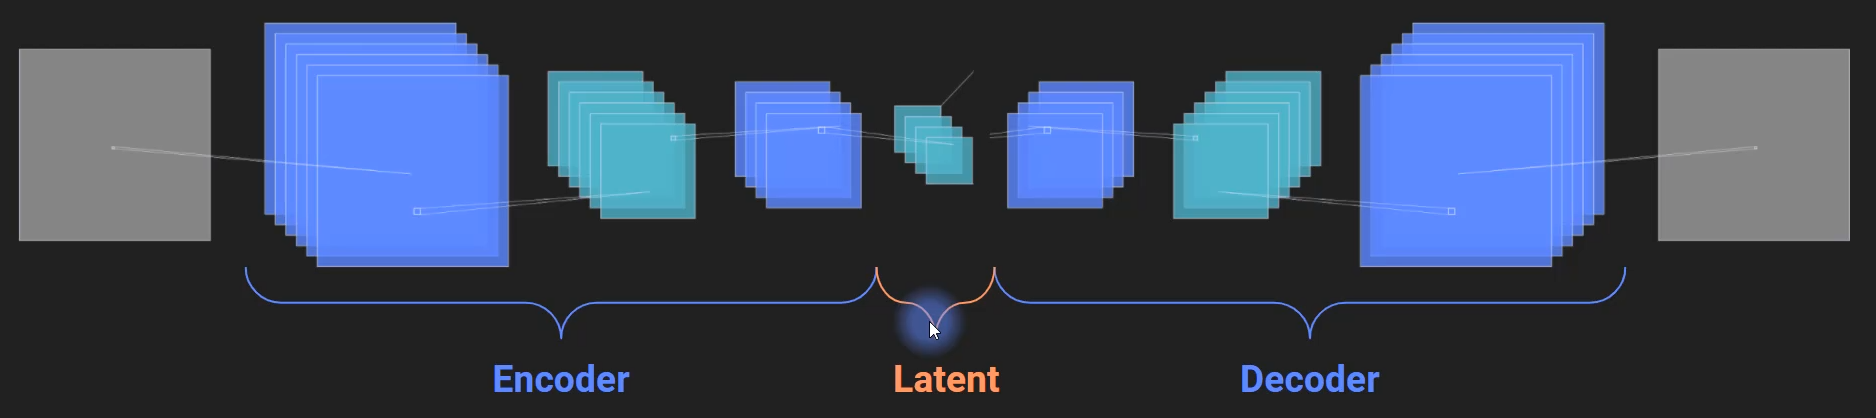

In [2]:
# create a guassian blur with different widths
n_per_class = 1000 # number of samples per class (total samples will be 2*1000 = 2000)
img_size = 91 # size of the images (91x91 pixels)

x = np.linspace(-4, 4, img_size)
X, Y = np.meshgrid(x, x)

class_widths = [1.8, 2.4] # class 0 will have a width of 1.8 and class 1 will have a width of 2.4

occluded_images = torch.zeros((2*n_per_class, 1, img_size, img_size)) # create a tensor to hold the occluded images
clean_images = torch.zeros((2*n_per_class, 1, img_size, img_size)) # create a tensor to hold the clean targets (without occlusion)
labels = torch.zeros(2*n_per_class, dtype=torch.long) # create a tensor to hold the labels

for i in range(2): # for each class
    for j in range(n_per_class): # for each sample in the class
        width = class_widths[i] # get the width for the class
        center = 2*np.random.randn(2) # randomly shift the center of the gaussian blur
        gauss = np.exp(-((X - center[0])**2 + (Y - center[1])**2) / (2 * width**2)) # create a gaussian blur with the given width and center
        gauss = gauss + np.random.randn(img_size, img_size) * 0.2 # add some noise to the image
        
        clean_images[i*n_per_class + j] = torch.tensor(gauss).view(1, img_size, img_size) # store the clean image in the tensor
        
        # add an horizontal or vertical bar of occlusion to the image
        bar_width = np.random.randint(2, 6) # random width of the bar
        starting_point = np.random.randint(2, 28) # random starting point of the bar between 2 and 28
        if np.random.rand() > 0.5: # horizontal bar
            gauss[starting_point:starting_point + bar_width, :] = 1
        else: # vertical bar
            gauss[:, starting_point:starting_point + bar_width] = 1

        occluded_images[i*n_per_class + j] = torch.tensor(gauss).view(1, img_size, img_size) # store the occluded image in the tensor
        labels[i*n_per_class + j] = i # store the label (0 for class 0 and 1 for class 1)

labels = labels.view(-1, 1) # reshape labels to be a column vector

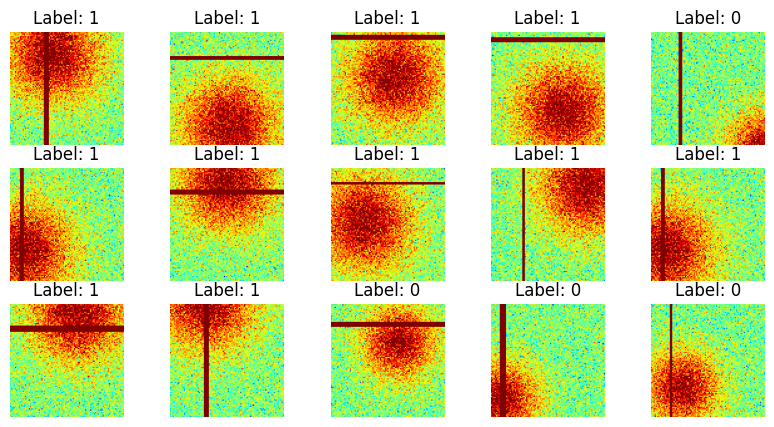

In [3]:
# visualize some occluded_images
fig, ax = plt.subplots(3, 5, figsize=(10, 5))

for i, ax in enumerate(ax.flatten()):
    random_pic = np.random.randint(0, 2*n_per_class) # randomly select an image from the dataset
    ax.imshow(occluded_images[random_pic].squeeze(), cmap='jet', vmin=-1, vmax=1)
    ax.set_title(f'Label: {labels[random_pic].item()}')
    ax.axis('off')

In [4]:
# create train and test dataloaders
X_train, X_test, y_train, y_test = train_test_split(occluded_images, labels, test_size=0.2, random_state=42)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

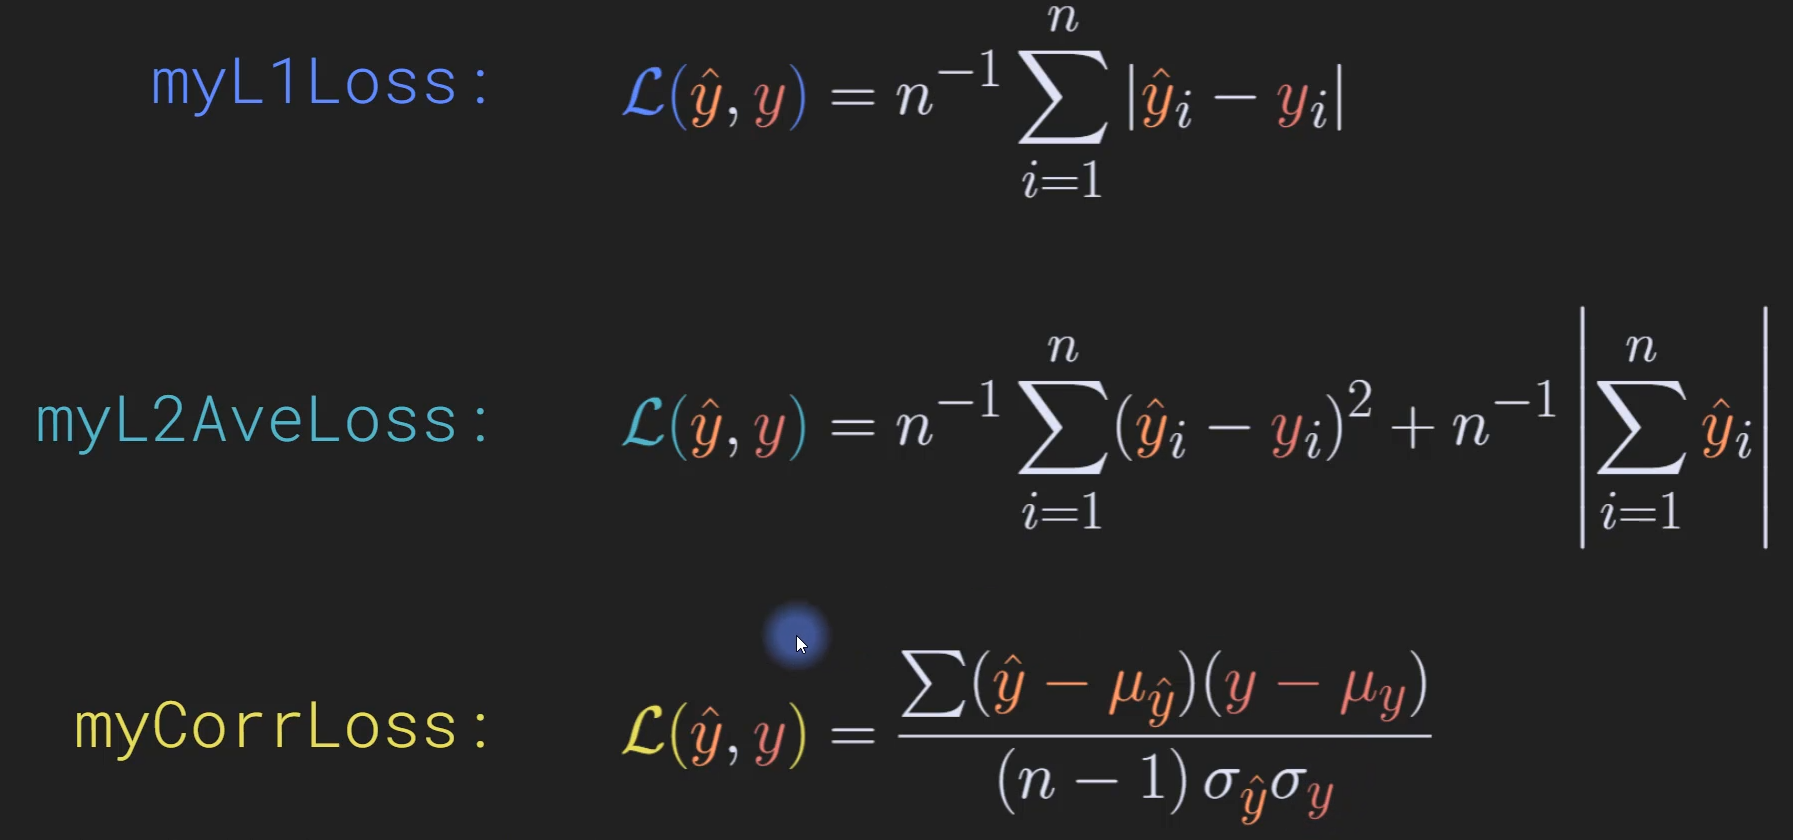

In [5]:
# create 3 custom loss functions
class CustomLoss1(nn.Module):
    def __init__(self):
        super(CustomLoss1, self).__init__()

    def forward(self, outputs, targets):
        # Mean Absolute Error Loss
        loss = torch.mean(torch.abs(outputs - targets)) # L1 loss function
        return loss
    
class CustomLoss2(nn.Module):
    def __init__(self):
        super(CustomLoss2, self).__init__()

    def forward(self, outputs, targets):
        # Mean Squared Error Loss
        loss = torch.mean((outputs - targets) ** 2) + torch.abs(torch.mean(outputs)) # L2 loss function with an additional term to encourage sparsity in the outputs
        return loss
    
class CustomLoss3(nn.Module):
    def __init__(self):
        super(CustomLoss3, self).__init__()

    def forward(self, outputs, targets):
        # Correlation Loss that measures the similarity between the outputs and targets
        outputs_mean = torch.mean(outputs)
        targets_mean = torch.mean(targets)
        numerator = torch.sum((outputs - outputs_mean) * (targets - targets_mean))
        denominator = (torch.numel(outputs) - 1) * torch.std(outputs) * torch.std(targets) # numel is the total number of elements in the outputs tensor
        loss = - numerator / (denominator + 1e-8) # we put (-) because we want to maximize the correlation between outputs and targets
        # if correlation is high, num/den will be high, therefore we put a negative sign to make the loss low when correlation is high
        return loss


In [6]:
class AutoEncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1), # output: (6, 91, 91)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output: (6, 45, 45)

            nn.Conv2d(in_channels=6, out_channels=4, kernel_size=3, stride=1, padding=1), # output: (4, 45, 45)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output: (4, 22, 22)
        )

        self.decoder = nn.Sequential(
            # conv tranpose to upsample the image back to the original size
            nn.ConvTranspose2d(in_channels=4, out_channels=6, kernel_size=3, stride=2, padding=0, output_padding=0), # output: (6, 45, 45)
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=6, out_channels=1, kernel_size=3, stride=2, padding=0, output_padding=0), # output: (1, 91, 91)
            nn.Sigmoid() # we want the output to be between 0 and 1 since we are reconstructing the image
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    
model = AutoEncoderCNN()
summary(model, input_size=(1, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
          Sigmoid-10            [-1, 1, 91, 91]               0
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.30
Params size (MB): 0.00
Estimated Total Siz

In [7]:
# test the model with a batch of data
# we have to ensure that the input and output shapes are correct before we start training the model, otherwise we might run into errors during training
model = AutoEncoderCNN()
images, labels = next(iter(train_dataloader))
outputs = model(images)
loss_fn = CustomLoss3() # You can choose CustomLoss1, CustomLoss2, or CustomLoss3
loss = loss_fn(outputs, images)
print(f"occluded_images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Loss: {loss.item()}")

occluded_images shape: torch.Size([32, 1, 91, 91])
Labels shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1, 91, 91])
Loss: -0.0018437148537486792


In [8]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int = 5,
          ):

    for epoch in range(epochs):
        model.train()
        for batch, (X, y) in enumerate(train_dataloader):
            # Forward pass
            X_reconstructed = model(X)
            loss = loss_fn(X_reconstructed, X)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


In [9]:
model1 = AutoEncoderCNN()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001)

model2 = AutoEncoderCNN()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)

model3 = AutoEncoderCNN()
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.001)

epochs = 10

train(model1, train_dataloader, CustomLoss1(), optimizer1, epochs)
train(model2, train_dataloader, CustomLoss2(), optimizer2, epochs)
train(model3, train_dataloader, CustomLoss3(), optimizer3, epochs)

Epoch 1/10, Loss: 0.3123
Epoch 2/10, Loss: 0.2421
Epoch 3/10, Loss: 0.2041
Epoch 4/10, Loss: 0.1909
Epoch 5/10, Loss: 0.1847
Epoch 6/10, Loss: 0.1781
Epoch 7/10, Loss: 0.1720
Epoch 8/10, Loss: 0.1687
Epoch 9/10, Loss: 0.1656
Epoch 10/10, Loss: 0.1646
Epoch 1/10, Loss: 0.5757
Epoch 2/10, Loss: 0.3296
Epoch 3/10, Loss: 0.2517
Epoch 4/10, Loss: 0.2282
Epoch 5/10, Loss: 0.2236
Epoch 6/10, Loss: 0.2391
Epoch 7/10, Loss: 0.2319
Epoch 8/10, Loss: 0.2508
Epoch 9/10, Loss: 0.2244
Epoch 10/10, Loss: 0.2326
Epoch 1/10, Loss: -0.7133
Epoch 2/10, Loss: -0.7798
Epoch 3/10, Loss: -0.7913
Epoch 4/10, Loss: -0.7968
Epoch 5/10, Loss: -0.8061
Epoch 6/10, Loss: -0.8187
Epoch 7/10, Loss: -0.8183
Epoch 8/10, Loss: -0.8258
Epoch 9/10, Loss: -0.8253
Epoch 10/10, Loss: -0.8248


In [10]:
model2 = AutoEncoderCNN()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
train(model2, train_dataloader, CustomLoss2(), optimizer2, epochs)

Epoch 1/10, Loss: 0.4870
Epoch 2/10, Loss: 0.3168
Epoch 3/10, Loss: 0.2652
Epoch 4/10, Loss: 0.2269
Epoch 5/10, Loss: 0.2417
Epoch 6/10, Loss: 0.2291
Epoch 7/10, Loss: 0.2265
Epoch 8/10, Loss: 0.2466
Epoch 9/10, Loss: 0.2373
Epoch 10/10, Loss: 0.2418


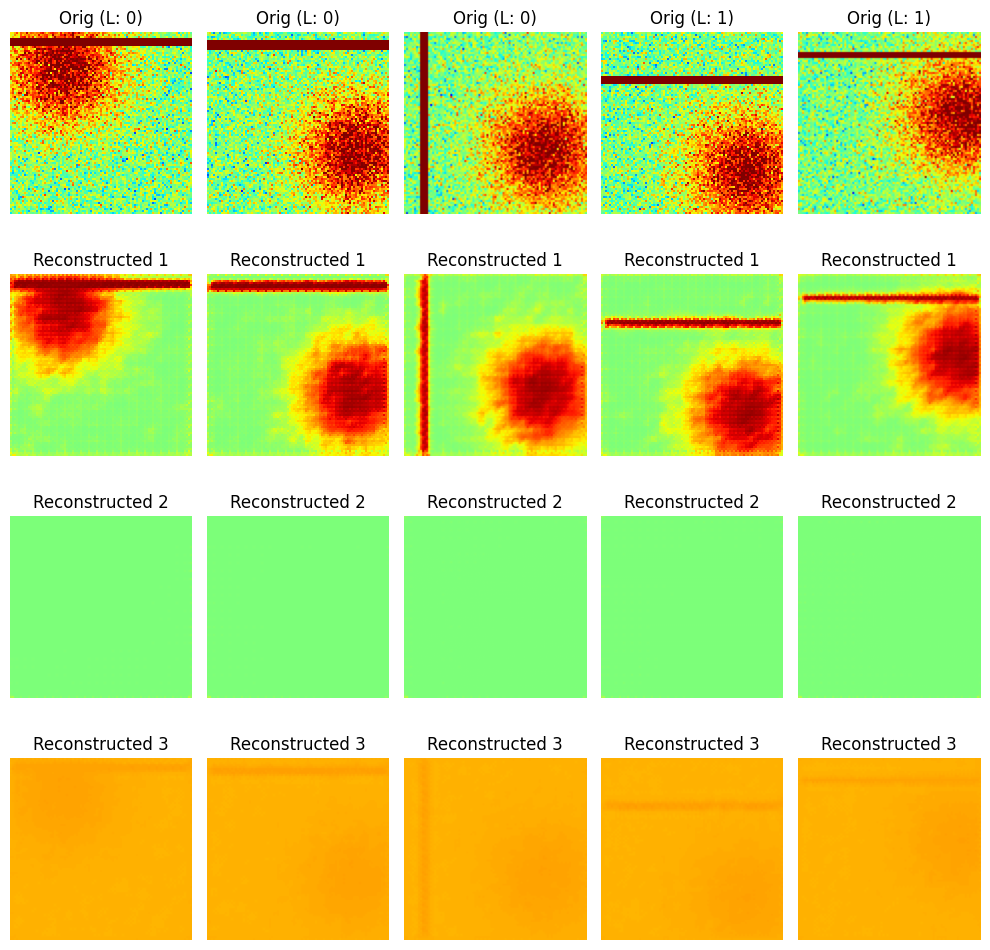

In [11]:
# Create a 4x5 grid
fig, axs = plt.subplots(4, 5, figsize=(10, 10))

for i in range(5):
    # 1. Select a random image
    random_pic = np.random.randint(0, 32)
    img_tensor = occluded_images[random_pic]
    
    # 2. Get images ready
    original_image = img_tensor.squeeze().numpy()
    reconstructed_image1 = model1(img_tensor.unsqueeze(0)).squeeze().detach().numpy()
    reconstructed_image2 = model2(img_tensor.unsqueeze(0)).squeeze().detach().numpy()
    reconstructed_image3 = model3(img_tensor.unsqueeze(0)).squeeze().detach().numpy()
    
    # 3. Plot Original (Top Row)
    axs[0, i].imshow(original_image, cmap='jet', vmin=-1, vmax=1)
    axs[0, i].set_title(f'Orig (L: {labels[random_pic].item()})')
    axs[0, i].axis('off')
    
    axs[1, i].imshow(reconstructed_image1, cmap='jet', vmin=-1, vmax=1)
    axs[1, i].set_title('Reconstructed 1')
    axs[1, i].axis('off')

    axs[2, i].imshow(reconstructed_image2, cmap='jet', vmin=-1, vmax=1)
    axs[2, i].set_title('Reconstructed 2')
    axs[2, i].axis('off')

    axs[3, i].imshow(reconstructed_image3, cmap='jet', vmin=-1, vmax=1)
    axs[3, i].set_title('Reconstructed 3')
    axs[3, i].axis('off')

plt.tight_layout()
plt.show()

# so we see that the autoencoder is not able to avoid the oclussion in the images, since the image is reconstructed with the bar
